In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

In [50]:
df=pd.read_csv('winequalityN.csv')

In [51]:
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [52]:
df['type'].value_counts()

type
white    4898
red      1599
Name: count, dtype: int64

In [53]:
df.columns

Index(['type', 'fixed acidity', 'volatile acidity', 'citric acid',
       'residual sugar', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
       'quality'],
      dtype='object')

In [54]:
df.shape

(6497, 13)

In [55]:
df.isnull().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

In [56]:
df['fixed acidity'].fillna(df['fixed acidity'].median(),inplace=True)
df['volatile acidity'].fillna(df['volatile acidity'].median(),inplace=True)
df['citric acid'].fillna(df['citric acid'].median(),inplace=True)
df['residual sugar'].fillna(df['residual sugar'].median(),inplace=True)
df['chlorides'].fillna(df['chlorides'].median(),inplace=True)
df['pH'].fillna(df['pH'].median(),inplace=True)
df['sulphates'].fillna(df['sulphates'].median(),inplace=True)

C:\Users\DANISH JAIN\AppData\Local\Temp\ipykernel_8920\2324188916.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['fixed acidity'].fillna(df['fixed acidity'].median(),inplace=True)
C:\Users\DANISH JAIN\AppData\Local\Temp\ipykernel_8920\2324188916.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

In [57]:
df.isnull().sum()

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [58]:
y=df['quality']
X=df.drop('quality',axis=1)

In [59]:
numeric_features = X.select_dtypes(exclude=['object']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[numeric_features] = scaler.fit_transform(X[numeric_features])

In [61]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical_features:
    X[col] = le.fit_transform(X[col])

In [62]:
##  Applying PCA Algorithms
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
data_pca=pca.fit_transform(X)
print(data_pca)

[[ 2.57815493  3.22152519]
 [-0.04309422 -0.51557713]
 [ 0.21841049  0.37487075]
 ...
 [-2.36218752 -0.53826745]
 [-2.57030573 -0.51869384]
 [-1.36070264 -0.42895774]]


In [63]:
pca.explained_variance_

array([3.16115945, 2.50596892])

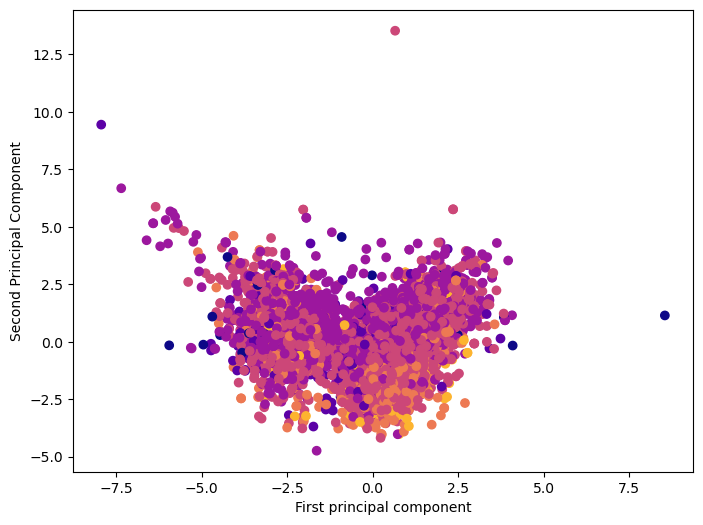

In [64]:
plt.figure(figsize=(8,6))
plt.scatter(data_pca[:,0],data_pca[:,1],c=df['quality'],cmap='plasma')
plt.xlabel('First principal component')
plt.ylabel('Second Principal Component')
plt.show()

In [65]:
y.unique()

array([6, 5, 7, 8, 4, 3, 9], dtype=int64)

In [66]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    data_pca, y, test_size=0.33, random_state=42)

In [67]:
from sklearn.cluster import KMeans

In [68]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [69]:
wcss

[24638.5218191217,
 15948.360551338668,
 7008.409577362849,
 5837.7391344487305,
 4460.025056466739,
 4031.36093502964,
 3434.1956301196005,
 3028.5979990720675,
 2810.554660416511,
 2518.651465278866]

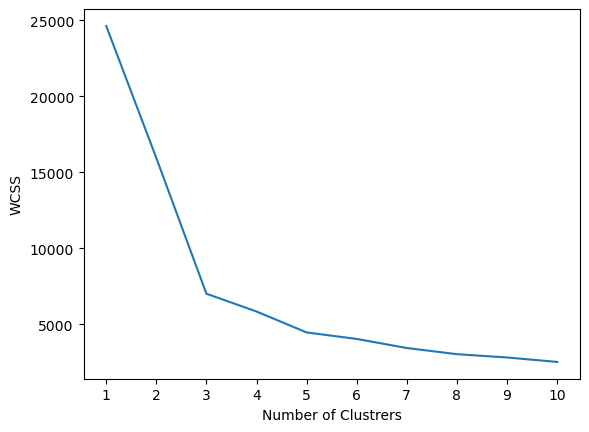

In [70]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [71]:
kmeans=KMeans(n_clusters=7,init="k-means++")

In [72]:
kmeans.fit_predict(X_train)

array([0, 1, 3, ..., 5, 4, 0])

In [73]:
y_pred=kmeans.predict(X_test)

In [74]:
y_pred

array([3, 0, 6, ..., 2, 3, 0])

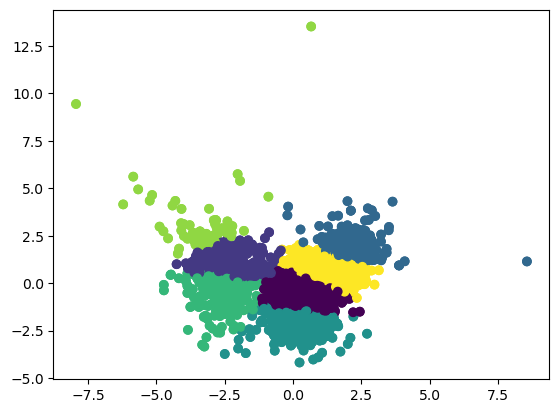

In [76]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)
plt.show()